# Dataset 3 - Rice Grains

**Implementation:** Akshith Karthik (`algorithms/akshit/`)  
**Algorithms:** k-NN, Decision Tree, Gaussian Naive Bayes  
**Evaluation:** Stratified 10-fold CV, Accuracy, F1-score

In [1]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['git', 'clone', f'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

if '.' not in sys.path:
    sys.path.insert(0, '.')


## Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import from your GitHub directories
from algorithms.akshit.hw_1 import knn_predict, normalize
from algorithms.akshit.hw_3 import RandomForest, evaluate_metrics, stratified_kfold, DecisionTree
from algorithms.vishal import utils
from algorithms.akshit.hw_2_naive_bayes import GaussianNaiveBayes

# --- Data Loading ---
df = pd.read_csv('data/rice.csv')

# UPDATED: Using 'label' instead of 'Class'
target_col = 'label'

X_raw = df.drop(columns=[target_col]).values.astype(float)
y = df[target_col].values.astype(str)

print(f"Instances: {len(y)}, Features: {X_raw.shape[1]}")
print(f"Classes: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Columns: {list(df.columns)}")


Instances: 3810, Features: 7
Classes: {np.str_('Cammeo'): np.int64(1630), np.str_('Osmancik'): np.int64(2180)}
Columns: ['attr1_num', 'attr2_num', 'attr3_num', 'attr4_num', 'attr5_num', 'attr6_num', 'attr7_num', 'label']


## Algorithm 1: k-NN Hyperparameter Sweep

In [6]:
# --- Algorithm 1 Sweep: k-NN ---
k_values = [1, 3, 5, 7, 9, 11]
knn_results = {'k': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for k-NN...")
folds = stratified_kfold(X_raw, y, k=10)

for k in k_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Normalize strictly within the fold
        X_tr_n, X_te_n = normalize(X_tr, X_te)

        # Predict
        y_pred = knn_predict(X_tr_n, list(y_tr), X_te_n, k)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    knn_results['k'].append(k)
    knn_results['accuracy'].append(np.mean(acc_list))
    knn_results['f1'].append(np.mean(f1_list))
    print(f"k={k:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")


Running 10-Fold CV for k-NN...
k=1  | Acc: 0.8861 | F1: 0.8999
k=3  | Acc: 0.9113 | F1: 0.9226
k=5  | Acc: 0.9226 | F1: 0.9325
k=7  | Acc: 0.9231 | F1: 0.9330
k=9  | Acc: 0.9244 | F1: 0.9342
k=11 | Acc: 0.9239 | F1: 0.9337


## Algorithm 2: Decision Tree Hyperparameter Sweep

In [4]:
from algorithms.akshit.hw_1_decision_tree import DecisionTree

# --- Algorithm 2 Sweep: Decision Tree ---
depth_values = [2, 3, 4, 5, 6, 7]
dt_results = {'max_depth': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Optimized Decision Tree...")
folds = stratified_kfold(X_raw, y, k=10)

for depth in depth_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Use the new Class
        dt = DecisionTree(max_depth=depth, min_size_for_split=5) # Increased min_size for even more speed
        dt.fit(X_tr, y_tr)

        y_pred = dt.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    dt_results['max_depth'].append(depth)
    dt_results['accuracy'].append(np.mean(acc_list))
    dt_results['f1'].append(np.mean(f1_list))
    print(f"max_depth={depth:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")



Running 10-Fold CV for Optimized Decision Tree...
max_depth=2  | Acc: 0.8958 | F1: 0.9027
max_depth=3  | Acc: 0.9121 | F1: 0.9267
max_depth=4  | Acc: 0.9278 | F1: 0.9364
max_depth=5  | Acc: 0.9257 | F1: 0.9352
max_depth=6  | Acc: 0.9294 | F1: 0.9385
max_depth=7  | Acc: 0.9273 | F1: 0.9364


## Algorithm 3: Gaussian Naive Bayes Hyperparameter Sweep

In [5]:
EPSILONS = [1e-9, 1e-7, 1e-5, 1e-3, 0.01, 0.1]
# Initialized to match the k-NN dictionary structure
nb_results = {'epsilon': [], 'accuracy': [], 'f1': []}

print("Running CV for Gaussian Naive Bayes Epsilon Sweep...")

for eps in EPSILONS:
    def model_fn(Xtr, ytr, Xte, eps=eps):
        # Import your Naive Bayes instead of Vishal's
        from algorithms.akshit.hw_2_naive_bayes import GaussianNaiveBayes
        import numpy as np

        # Initialize and fit the model
        gnb = GaussianNaiveBayes()
        gnb.fit(Xtr, ytr)

        # Patch the std floor for this run directly in the dictionary
        for c in gnb.classes:
            gnb.stds[c] = np.maximum(gnb.stds[c], eps)

        # Return the predictions
        return gnb.predict(Xte)

    # Run the cross-validation using your wrapper function
    # Tell the F1 calculator to track 'Cammeo' (or 'Osmancik') as the target class
    acc, f1 = utils.cross_validate(model_fn, X_raw, y, pos_label='Cammeo')

    # Append the results to the lists
    nb_results['epsilon'].append(eps)
    nb_results['accuracy'].append(acc)
    nb_results['f1'].append(f1)

    # Updated print statement to match the k-NN formatting
    print(f"eps={eps:<5} | Acc: {acc:.4f} | F1: {f1:.4f}")

Running CV for Gaussian Naive Bayes Epsilon Sweep...
eps=1e-09 | Acc: 0.9171 | F1: 0.9024
eps=1e-07 | Acc: 0.9168 | F1: 0.9021
eps=1e-05 | Acc: 0.9176 | F1: 0.9032
eps=0.001 | Acc: 0.9171 | F1: 0.9024
eps=0.01  | Acc: 0.9171 | F1: 0.9024
eps=0.1   | Acc: 0.9105 | F1: 0.8946


## Plots and Summary Table

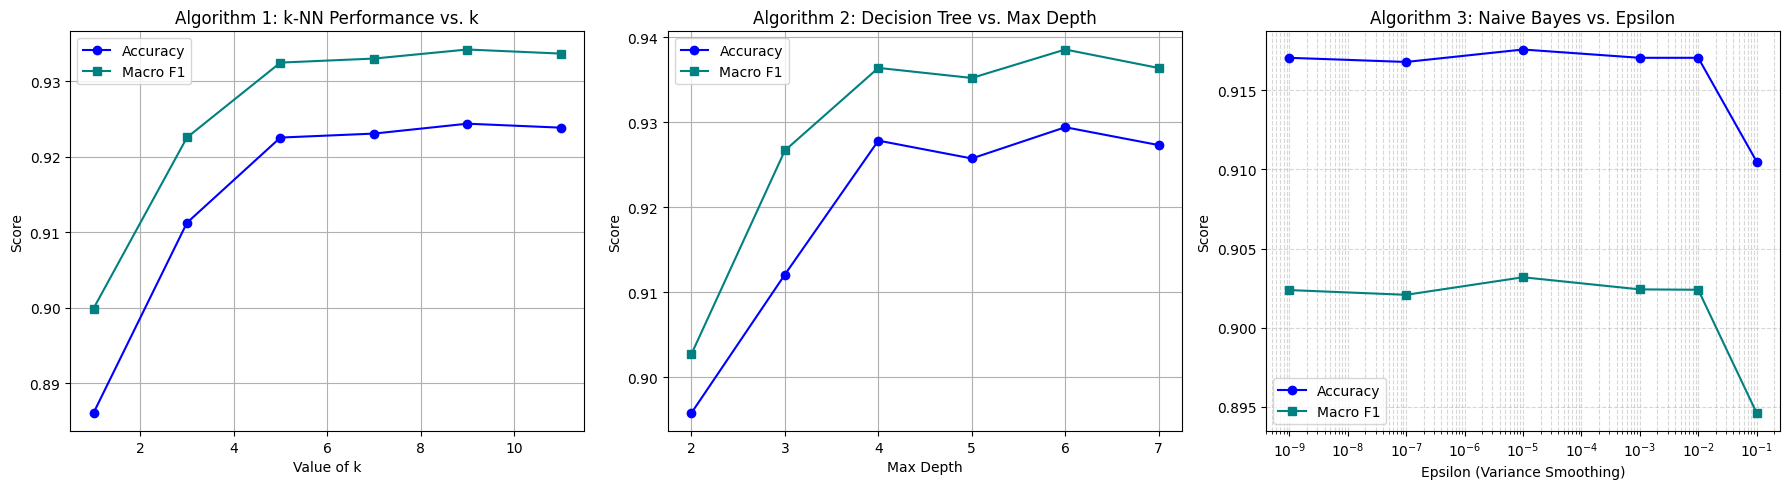


=== SUMMARY TABLE ===
k-NN Results:
 k  accuracy       f1
 1  0.886089 0.899926
 3  0.911286 0.922584
 5  0.922572 0.932503
 7  0.923097 0.933037
 9  0.924409 0.934237
11  0.923885 0.933696

Decision Tree Results:
 max_depth  accuracy       f1
         2  0.895801 0.902722
         3  0.912073 0.926661
         4  0.927822 0.936372
         5  0.925722 0.935188
         6  0.929396 0.938535
         7  0.927297 0.936361

Gaussian Naive Bayes Results:
epsilon  accuracy       f1
1.0e-09  0.917060 0.902372
1.0e-07  0.916798 0.902073
1.0e-05  0.917585 0.903182
1.0e-03  0.917060 0.902416
1.0e-02  0.917060 0.902392
1.0e-01  0.910499 0.894601


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('results', exist_ok=True)

# Extract the sweep values directly from the new dictionary structure
eps_values = nb_results['epsilon']
nb_acc_scores = nb_results['accuracy']
nb_f1_scores = nb_results['f1']

# --- Plotting Learning Curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-NN Plot
axes[0].plot(knn_results['k'], knn_results['accuracy'], marker='o', label='Accuracy', color='blue')
axes[0].plot(knn_results['k'], knn_results['f1'], marker='s', label='Macro F1', color='teal')
axes[0].set_title('Algorithm 1: k-NN Performance vs. k')
axes[0].set_xlabel('Value of k')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

# Decision Tree Plot
axes[1].plot(dt_results['max_depth'], dt_results['accuracy'], marker='o', label='Accuracy', color='blue')
axes[1].plot(dt_results['max_depth'], dt_results['f1'], marker='s', label='Macro F1', color='teal')
axes[1].set_title('Algorithm 2: Decision Tree vs. Max Depth')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

# Gaussian Naive Bayes Plot (Epsilon Sweep)
axes[2].plot(eps_values, nb_acc_scores, marker='o', label='Accuracy', color='blue')
axes[2].plot(eps_values, nb_f1_scores, marker='s', label='Macro F1', color='teal')
axes[2].set_title('Algorithm 3: Naive Bayes vs. Epsilon')
axes[2].set_xlabel('Epsilon (Variance Smoothing)')
axes[2].set_ylabel('Score')
axes[2].set_xscale('log') # Sets the X-axis to logarithmic for the epsilons
axes[2].legend()
axes[2].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n=== SUMMARY TABLE ===")
print("k-NN Results:")
df_knn = pd.DataFrame(knn_results)
print(df_knn.to_string(index=False))

print("\nDecision Tree Results:")
df_dt = pd.DataFrame(dt_results)
print(df_dt.to_string(index=False))

print("\nGaussian Naive Bayes Results:")
# Since nb_results is now perfectly formatted, you can just pass it directly to pandas!
df_gnb = pd.DataFrame(nb_results)
# Format the epsilon column to scientific notation so it prints cleanly
df_gnb['epsilon'] = df_gnb['epsilon'].apply(lambda x: f"{x:.1e}")
print(df_gnb.to_string(index=False))